# Reconstructing Superoscillations Buried Deeply in Noise

Numerical analysis accompanying:

**D. D. White et al., "Reconstructing superoscillations buried deeply in noise,"  
Physical Review A 110, L061502 (2024).**

DOI: 10.1103/PhysRevA.110.L061502

This notebook contains the numerical construction of the frequency-comb superoscillation, parameter optimization, Fourier-domain analysis, and processing of the experimental measurements used to demonstrate reconstruction of noise-buried superoscillations and sub-bandwidth two-scatterer discrimination.

In [18]:
import sys
import scipy as sp
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from numpy import fft
from google.colab import drive
from matplotlib.lines import Line2D

# Core Functions

In [2]:
# Define the Fourier series function using only cosine terms
def fourier_series(t, coefficients, fmin, fmax, make_complex=False):
    result = np.zeros(len(t))
    N = len(coefficients)
    dw = (fmax-fmin)/(N-1)
    if make_complex:
        result = np.zeros(len(t), dtype=np.complex128)
        for k in range(0, N):
            result += coefficients[k] * np.exp(1j*2*np.pi*t*(fmin+(dw*k)))
    else:
        for k in range(0, N):
            result += coefficients[k] * np.cos(2*np.pi*t*(fmin+(dw*k)))
    return result

# Construct the design matrix
def get_fourier_fit(t, N, fmin, fmax):
    dw = (fmax-fmin)/(N-1)
    A = np.zeros((len(t), N))
    for k in range(0, N):
        A[:, k] = np.cos(2*np.pi*t*(fmin+(dw*k)))
    return A

# Construct the design matrix (for odd functions)
def get_fourier_fit_odd(t, N, fmin, fmax):
    dw = (fmax-fmin)/(N-1)
    A = np.zeros((len(t), N))
    for k in range(0, N):
        A[:, k] = np.sin(2*np.pi*t*(fmin+(dw*k)))
    return A

def dlog(wave):
    return np.diff(np.log(wave))

# Create the Wave

### create target function to fit to

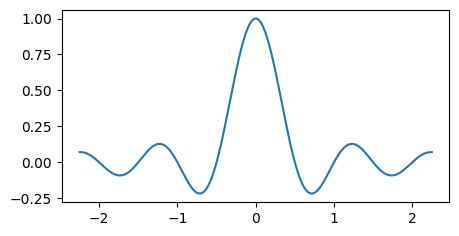

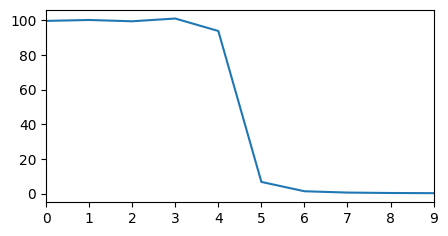

In [24]:
res                 = 200                       # number of time steps per target signal's inverse bandwidth (1/B)
_sincwidth          = 4.5                       # length of target signal in unit of inverse bandwidth
_sinclength         = int(res*_sincwidth)       # number of time steps in target signal
_t                  = np.linspace(-_sincwidth/2, _sincwidth/2, _sinclength)
_sinc               = np.sin(_t*np.pi*2)/(_t*np.pi*2)
_sinc[_t == 0.0]    = 1.0

plt.rcParams['figure.dpi']      = 100
plt.rcParams['figure.figsize']  = (5,2.5)

plt.plot(_t, _sinc)
plt.show()

plt.plot(np.abs(np.fft.fft(_sinc)))
plt.xlim(0,_sincwidth*2)
plt.show()

### find the best fit

Run a grid search across the number of frequencies, minimum frequency, and bandwidth to find how these parameters affect the fit error in the superoscillating region and the amplitude of the signal outside the superoscillating region. We want to minimize both of these as much as possible - we want high quality reconstruction of the target function while keeping lobe size from exploding.

Bandwidth and frequency are described here in units of the bandwidth of the target sinc function, such that the superoscillating wave's component frequencies and resulting bandwidth will be fractions of this number.

In [51]:
results     = []    # N, Omega, omega_min, max amp, MSE
for N in np.arange(3, 16):
    print('N =', N)
    for freqspread in np.arange(.1, .501, .05):
        print('  freqspread =', round(freqspread,2))
        cyclewidth  = (N-1)/freqspread
        ratio       = cyclewidth/_sincwidth
        for minfreq in np.arange(0, .901, .005):
            maxfreq = minfreq + freqspread

            A       = get_fourier_fit(_t, N, minfreq, maxfreq)
            coefs, _, _, _ = sp.linalg.lstsq(A, _sinc)

            t_wave  = np.linspace(-_sincwidth*ratio/2, _sincwidth*ratio/2, int(_sinclength*ratio))
            t_wave2 = np.linspace(-_sincwidth/2, _sincwidth/2, _sinclength)
            y_wave  = fourier_series(t_wave, coefs, minfreq, maxfreq)
            y_wave2 = fourier_series(t_wave2, coefs, minfreq, maxfreq)
            _max    = max(np.abs(y_wave))
            _mean   = np.mean((np.real(_sinc)-np.real(y_wave2))**2)
            y_temp  = np.copy(y_wave2)
            y_temp *= 1 + np.cos(t_wave2*np.pi*2/_sincwidth)

            results.append([N, freqspread, minfreq, _max, _mean])

results_db  = pd.DataFrame(results, columns=['N', 'freqspread', 'minfreq', 'max amp', 'MSE'])

N = 3
  freqspread = 0.1
  freqspread = 0.15
  freqspread = 0.2
  freqspread = 0.25
  freqspread = 0.3
  freqspread = 0.35
  freqspread = 0.4
  freqspread = 0.45
  freqspread = 0.5
N = 4
  freqspread = 0.1
  freqspread = 0.15
  freqspread = 0.2
  freqspread = 0.25
  freqspread = 0.3
  freqspread = 0.35
  freqspread = 0.4
  freqspread = 0.45
  freqspread = 0.5
N = 5
  freqspread = 0.1
  freqspread = 0.15
  freqspread = 0.2
  freqspread = 0.25
  freqspread = 0.3
  freqspread = 0.35
  freqspread = 0.4
  freqspread = 0.45
  freqspread = 0.5
N = 6
  freqspread = 0.1
  freqspread = 0.15
  freqspread = 0.2
  freqspread = 0.25
  freqspread = 0.3
  freqspread = 0.35
  freqspread = 0.4
  freqspread = 0.45
  freqspread = 0.5
N = 7
  freqspread = 0.1
  freqspread = 0.15
  freqspread = 0.2
  freqspread = 0.25
  freqspread = 0.3
  freqspread = 0.35
  freqspread = 0.4
  freqspread = 0.45
  freqspread = 0.5
N = 8
  freqspread = 0.1
  freqspread = 0.15
  freqspread = 0.2
  freqspread = 0.25
  freqsprea

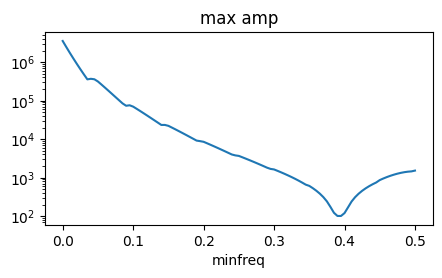

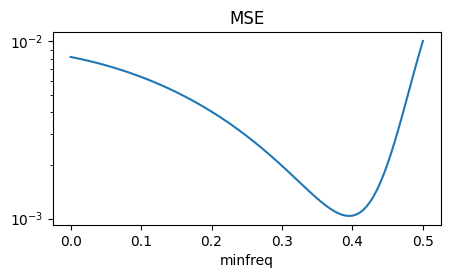

In [5]:
# for a prescribed N and bandwidth, find a minimum frequency that minimizes
# both superoscillation MSE and maximum lobe amplitude

n           = 6
f_spread    = .25
target      = results_db[(np.round(results_db['N'], 2) == n) &
                        (np.round(results_db['freqspread'], 2) == f_spread)]

plt.plot(target['minfreq'], target['max amp'])
plt.title('max amp')
plt.xlabel('minfreq')
plt.yscale('log')
plt.show()

plt.plot(target['minfreq'], target['MSE'])
plt.title('MSE')
plt.xlabel('minfreq')
plt.yscale('log')
plt.show()

### generate the superfunction

In [6]:
# with six frequencies and bandwidth 'freqspread' of 0.25*B, each frequency is spaced by 0.05*B.
# we therefore set minfreq at 0.4, as it is the nearest multiple of 0.05 to the minimizing value of ~0.39
# (from above plots)

N           = 6                         # number of frequencies in the superoscillating functions
freqspread  = .25                       # bandwidth of the superoscillating function, in units of B
minfreq     = .4                        # slowest frequency of the superoscillating function, in units of B
cyclewidth  = (N-1)/freqspread          # temporal length of one period of superoscillating function in units of 1/B
cyclelen    = int(cyclewidth * res)     # total time steps of one period of superoscillating function
maxfreq     = minfreq + freqspread      # fastest frequency of superoscillating function in units of B
ratio       = _sincwidth/cyclewidth     # what percentage of superoscillating function mimics the target function
realinvbw   = int(res/freqspread)       # number of time steps per inverse bandwidth of the superoscillating function

print('real inverse bandwidth (# time steps):', realinvbw)
print('total time steps:', cyclelen)
print('# inverse bandwidths:', int(cyclelen/realinvbw))
print('N:', N)
print('frequency spread:', freqspread)
print('smallest frequency:', minfreq)
print('cycle width:', cyclewidth)
print('superregion width:', _sincwidth)
print('ratio:', ratio)

A = get_fourier_fit(_t, N, minfreq, maxfreq)
coefs, _, _, _ = sp.linalg.lstsq(A, _sinc)

print('')
print('frequencies:', [float(np.round(i, 4)) for i in np.linspace(minfreq, maxfreq, N)])
print('amplitudes:', [float(i) for i in coefs])

real inverse bandwidth (# time steps): 800
total time steps: 4000
# inverse bandwidths: 5
N: 6
frequency spread: 0.25
smallest frequency: 0.4
cycle width: 20.0
superregion width: 4.5
ratio: 0.225

frequencies: [0.4, 0.45, 0.5, 0.55, 0.6, 0.65]
amplitudes: [17.618446533232163, -50.26975707517404, 49.60664737147208, -7.953358843512094, -16.828304842533502, 8.784849260481101]


### visual checks

Plot the superoscillating wave against the target sinc in time and frequency domains.

The superoscillating wave fairly accurately mimics the target sinc over the designated interval in both time and frequency domains, while using only a fraction of the total bandwidth.

In [7]:
# 10 periods of the superoscillating wave
mult                = 10
t_wave              = np.linspace(-cyclewidth*mult/2, cyclewidth*mult/2, int(cyclelen*mult), endpoint=False)
y_wave              = fourier_series(t_wave, coefs, minfreq, maxfreq, make_complex=True)
freqs               = np.fft.fftfreq(len(y_wave), d=1/res)
fft_wave            = np.fft.fft(y_wave)

# just the superoscillating section, for comparison against the target function
y_wave2             = y_wave[int(len(y_wave)/2)-int(_sinclength/2):int(len(y_wave)/2)+int(_sinclength/2)]
t_wave2             = t_wave[int(len(t_wave)/2)-int(_sinclength/2):int(len(t_wave)/2)+int(_sinclength/2)]
freqs2              = np.fft.fftshift(np.fft.fftfreq(len(y_wave2), d=1/res))
fft_wave2           = np.fft.fftshift(np.fft.fft(np.real(y_wave2)))

# fft of the original target function
fft_sinc            = np.fft.fftshift(np.fft.fft(_sinc))
freqs_sinc          = np.fft.fftshift(np.fft.fftfreq(len(_sinc), d=1/res))

Plots of the resulting function compared to the target sinc function. X-axis in units of the target sinc's bandwidth (for frequency domain) and inverse bandwidth (for time domain).

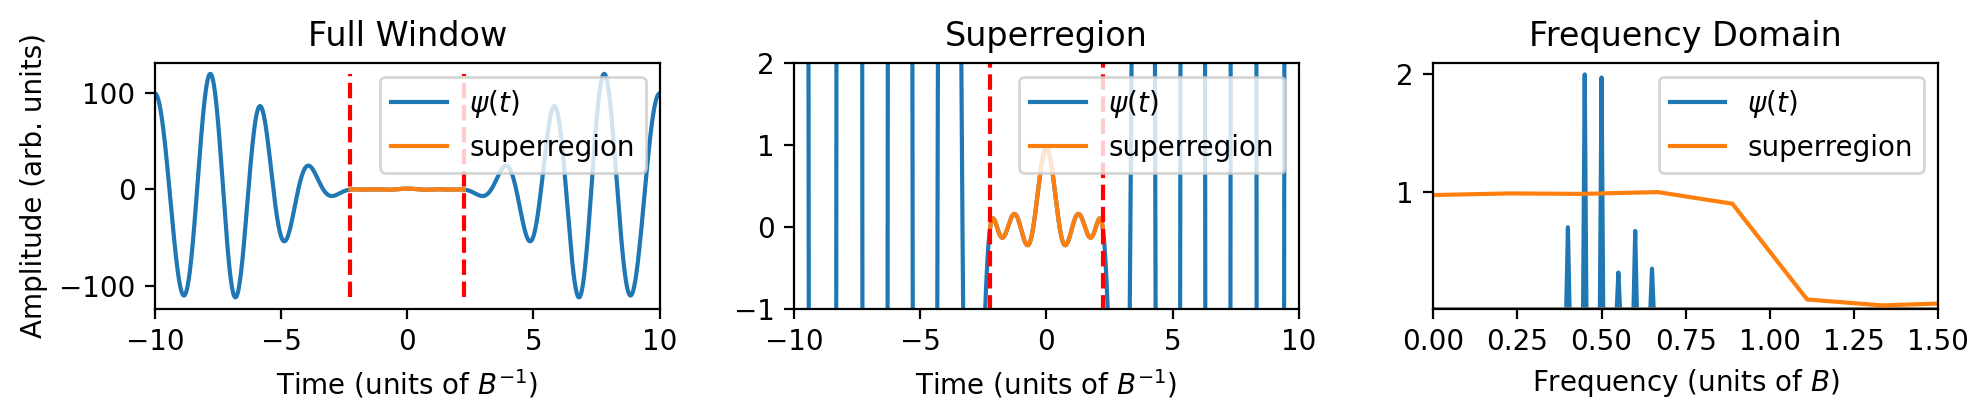

In [8]:
# Compute the FFT
dt=1/res

frequencies     = np.fft.fftfreq(len(y_wave), d=dt)
frequencies2    = np.fft.fftfreq(len(y_wave2), d=dt)
freq2           = np.fft.fftfreq(len(_sinc), d=dt)

fplot           = np.abs(np.fft.fft(y_wave))
fplot2          = np.abs(np.fft.fft(np.real(y_wave2)))
splot           = np.abs(np.fft.fft(_sinc))
super           = y_wave[int(len(y_wave)/2)-int(_sinclength/2):int(len(y_wave)/2)+int(_sinclength/2)]

fig, axs        = plt.subplots(1, 3, figsize=(10,2.2), dpi=200)

axs[0].plot(t_wave, np.real(y_wave), label=r'$\psi(t)$')
axs[0].plot(t_wave2, np.real(super), label='superregion')
axs[0].vlines([-_sincwidth/2, _sincwidth/2], min(np.real(y_wave)), max(np.real(y_wave)), linestyles='dashed', color='r')
axs[0].legend(loc='upper right')
axs[0].set_xlim(-cyclewidth/2, cyclewidth/2)
axs[0].set_xlabel(r'Time (units of $B^{-1}$)')
axs[0].set_ylabel('Amplitude (arb. units)')
axs[0].set_title('Full Window')

axs[1].plot(t_wave, np.real(y_wave), label=r'$\psi(t)$')
axs[1].plot(t_wave2, np.real(super), label='superregion')
axs[1].vlines([-_sincwidth/2, _sincwidth/2], min(np.real(y_wave)), max(np.real(y_wave)), linestyles='dashed', color='r')
axs[1].legend(loc='upper right')
axs[1].set_xlim(-10, 10)
axs[1].set_ylim(-1, 2)
axs[1].set_xlabel(r'Time (units of $B^{-1}$)')
axs[1].set_title('Superregion')

axs[2].plot(frequencies, fplot*2/np.max(fplot), label=r'$\psi(t)$')
axs[2].plot(frequencies2, fplot2/np.max(fplot2), label='superregion')
axs[2].legend(loc='upper right')
axs[2].set_xlim(0, 1.5)
axs[2].set_ylim(.01, 2.1)
axs[2].set_xlabel(r'Frequency (units of $B$)')
axs[2].set_title('Frequency Domain')

plt.tight_layout()
plt.show()

Plot of signal frequency as function of time. The blue band indicates the component frequencies used to construct the superoscillating wave. While the signal's side lobes remain inside this band, instantaneous frequencies slower than the slowest global component frequency and faster than the fastest global component frequency are seen throughout the superoscillating region.

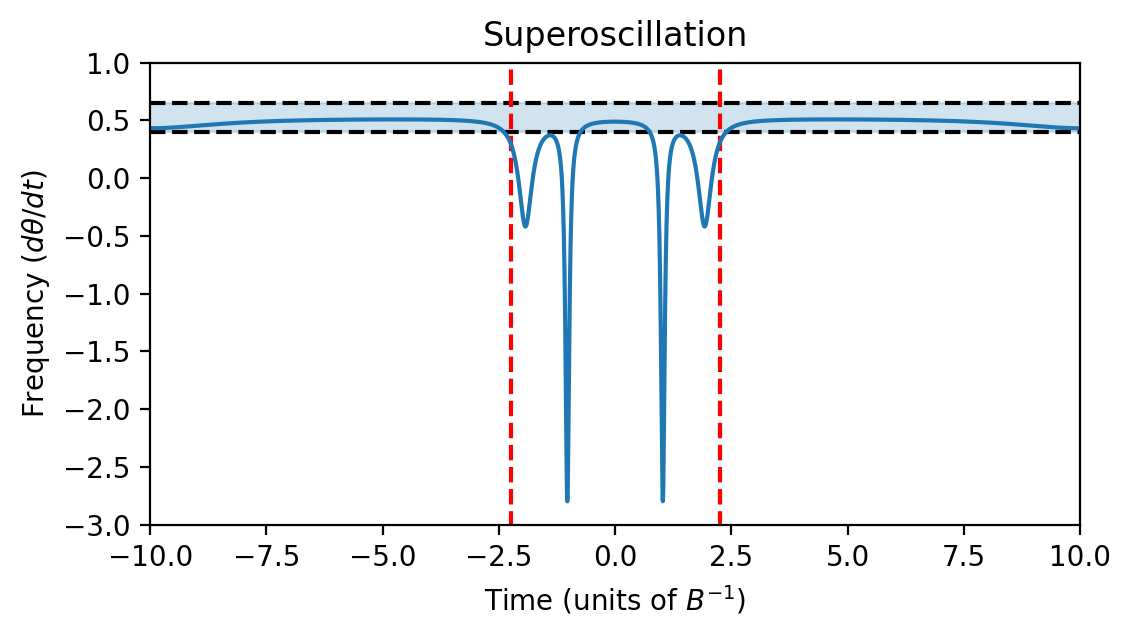

In [9]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = (6,3)

plt.title('Superoscillation')
plt.fill_between(t_wave[:-1], .4, .65, alpha=.2, color='tab:blue')
plt.hlines((.4, .65), -cyclewidth/2, cyclewidth/2, linestyles='dashed', color='black')
plt.vlines([-2*(9/8), 2*(9/8)], min(np.real(y_wave)), max(np.real(y_wave)),
              linestyles='dashed', color='r')
plt.plot(t_wave[:-1], np.diff(np.unwrap(np.angle(y_wave)))*res/(2*np.pi), color='tab:blue')
plt.xlim(-cyclewidth/2, cyclewidth/2)
plt.ylim(-3, 1)
plt.xlabel(r'Time (units of $B^{-1}$)')
plt.ylabel(r'Frequency ($d\theta/dt$)')
plt.show()

### save the newly constructed wave

In [10]:
max_amp = np.max(np.abs(y_wave))
y_wave /= max_amp       # scale to [0,1] to work with function generator in lab

np.savetxt('6peaks_40000.csv', np.real(y_wave))

# Import and Process Lab Data

Once saved as .csv, the files are loaded into a function generator and transmitted through BNC cables at low amplitude to ensure the presence of substantial noise relative to the amplitude of the wave's superoscillations. See paper for more information on this section, as well as how we created two travel paths of varying lengths for the signal in order to mimic delta-like scattering objects.

### zero-separation case

In [52]:
# spectral removal of noise from time series data
# returns multiple sampled realizations of the return signal after spectral removal of noise
#   - only processing the real portion of the fft should make the iffts all phase-aligned
#   - removing all negative frequencies makes the ifft a complex wave, so we can use all
#     the benefits of superoscillation and supergrowth analysis
def get_reconstructions(arr, count, cyclen, N, numcycles, printpeaks=False, real=True):
    wavesarr            = [np.zeros(cyclen, dtype=np.complex128) for i in range(count)]
    for i in range(count):
        cycle           = arr[i*cyclen*numcycles:(i+1)*cyclen*numcycles]    # pick the next cycle in the series
        sc_fft          = np.fft.fft(cycle)
        # zero out troublesome low frequencies from collected 'scope data that sometimes have too large of amplitude
        sc_fft[:7]      = 0
        # find locations of target frequencies. this assumes each frequency is not drowned in noise
        peaks           = np.sort(np.argsort(np.abs(sc_fft))[-N*2:])[:N]
        if printpeaks:
            print(peaks)
        mask            = np.zeros_like(sc_fft, dtype=bool)
        mask[peaks]     = True
        sc_fft[~mask]   = 0                             # Zero out elements not in peaks
        if real:
            wavesarr[i] = np.real(np.fft.ifft(sc_fft))
        else:
            wavesarr[i] = np.fft.ifft(sc_fft)
    return wavesarr

# given a starting time (for phase alignment), return multiple realizations of the cleaned signal
#   - numcycles:    how many periods of the return signal to analyze at once
#   - wavecount:    how many independent realizations to return
#   - cyclelen:     number of time steps in one period
#   - N:            number of frequencies to keep; all others are set to 0 (noise filtering)
def return_cleaned_signal(start, filename, cyclelen=10000, wavecount=10, numcycles=10, N=6):
    data_arr    = np.loadtxt(filename)
    filelen     = len(data_arr)
    data        = np.array(data_arr)[start:start+filelen]
    mid         = int(cyclelen/2)
    fullarr     = get_reconstructions(data, wavecount, cyclelen, N, numcycles)
    superarr    = [fullarr[i][mid-1125:mid+1125] for i in range(wavecount)]
    for i in range(wavecount):
        fullarr[i] -= np.mean(superarr[i])
    return fullarr

In [53]:
# process 100 different cycles by spectrally filtering each individually and store them in a new 2D array

cyclelen    = 10000         # number of time steps per one period of return wave
wavecount   = 10            # how many realizations to return
numcycles   = 10            # how many periods of the return wave are processed at once
N           = 6              # number of frequencies to keep; all others are set to 0 (noise filtering)
t_one_cycle = np.linspace(-2.5, 2.5, cyclelen)

In [54]:
# get noisy data from file

filename    = '6_10mV_8mV_0ft.csv'
data        = np.loadtxt(filename)

In [55]:
_0ft        = return_cleaned_signal(1163, '6_10mV_8mV_0ft.csv')

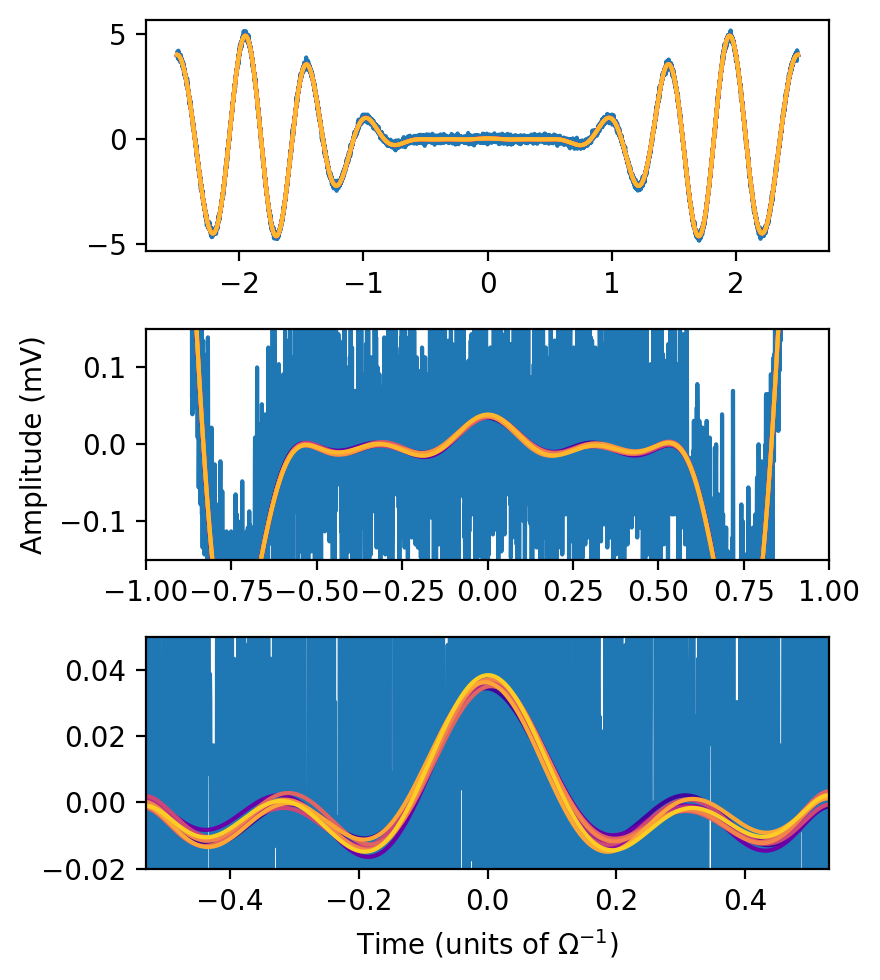

In [56]:
fig, axs = plt.subplots(3, 1, figsize=(4.5,5), dpi=200)

for i in range(3):
    axs[i].plot(t_one_cycle, data[1163:cyclelen+1163]*1000+.08)

for i in range(len(_0ft)):
    axs[0].plot(t_one_cycle, _0ft[i][:cyclelen]*2000, color=mpl.cm.plasma(i/(wavecount*1.07)))
    axs[1].plot(t_one_cycle, _0ft[i][:cyclelen]*2000, color=mpl.cm.plasma(i/(wavecount*1.07)))
    axs[2].plot(t_one_cycle, _0ft[i][:cyclelen]*2000, color=mpl.cm.plasma(i/wavecount))

axs[1].set_xlim(-1, 1)
axs[1].set_ylim(-.15, .15)
axs[1].set_ylabel('Amplitude (mV)')

axs[2].set_xlim(-.53, .53)
axs[2].set_ylim(-.02, .05)
axs[2].set_xlabel(r'Time (units of $\Omega^{-1}$)')

plt.tight_layout()
plt.show()

### show effect of delta-like scatterers
As difference in length between the two travel paths increases, the superoscillating portion of the signal becomes more distorted. This can be seen by fractions of the inverse bandwidth, well below the classically considered limit.

In [57]:
_0ft    = return_cleaned_signal(1163, '6_10mV_8mV_0ft.csv')
_10ft   = return_cleaned_signal(1110, '6_10mV_8mV_10ft.csv')
_20ft   = return_cleaned_signal(1110, '6_10mV_8mV_20ft.csv')
_30ft   = return_cleaned_signal(10, '6_10mV_8mV_30ft.csv')

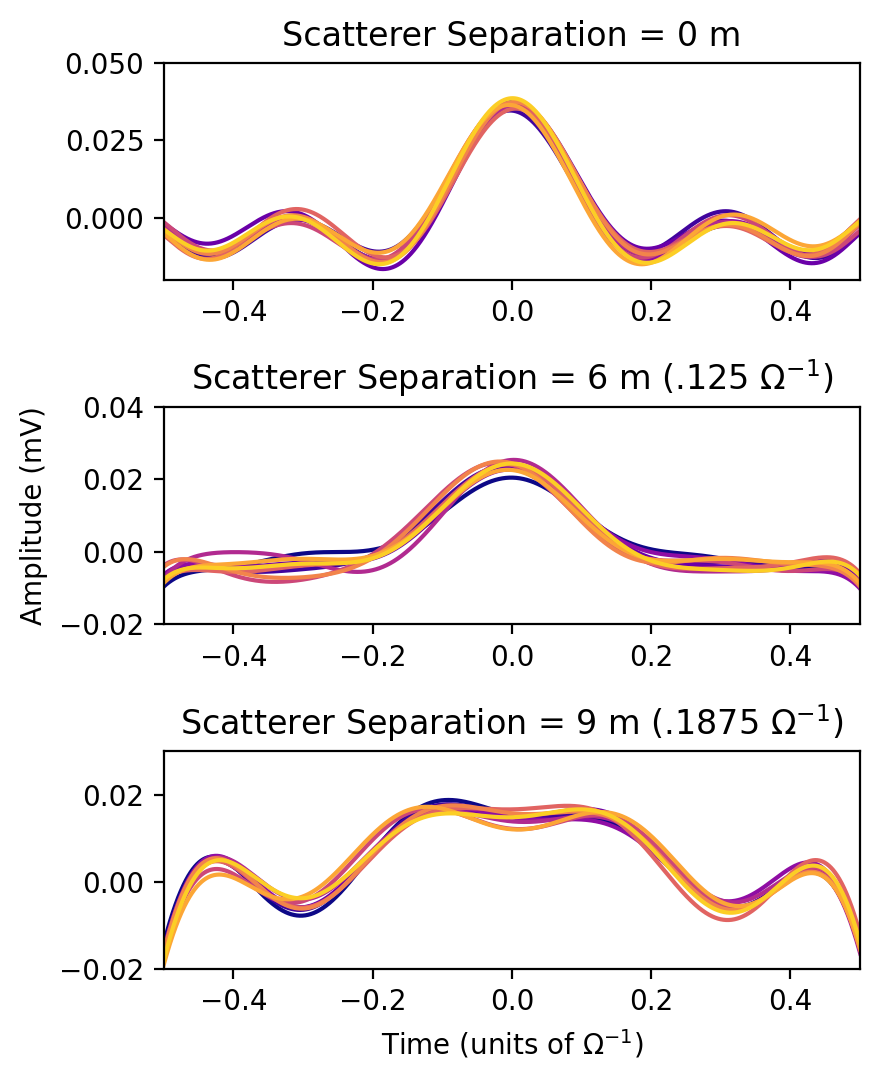

In [58]:
fig, axs = plt.subplots(3, 1, figsize=(4.5,5.5), dpi=200)

import matplotlib as mpl
k = 0

for i, k in enumerate([_0ft, _20ft, _30ft]):
    for j in range(wavecount):
        axs[i].plot(t_one_cycle, k[j][:cyclelen]*2000, color=mpl.cm.plasma(j/wavecount))
        axs[i].set_xlim(-.5, .5)
        axs[i].set_ylim(-.02, .05-i*.01)
axs[2].set_xlabel(r'Time (units of $\Omega^{-1}$)')
axs[1].set_ylabel('Amplitude (mV)')
axs[0].set_title('Scatterer Separation = 0 m')
axs[1].set_title(r'Scatterer Separation = 6 m (.125 $\Omega^{-1}$)')
axs[2].set_title(r'Scatterer Separation = 9 m (.1875 $\Omega^{-1}$)')
plt.tight_layout()
plt.show()

# Analyze Grid Search of Parameters for Best Fit

used in the Supplemental Material for the paper published from this research

In [59]:
mins = results_db.copy()
mins.columns = ['N', 'Omega', 'omega_min', 'amp', 'MSE']

In [60]:
# some data cleaning
mins['N'] = mins['N'].astype(int)
mins['Omega'] = np.round(mins['Omega'], 3)

mins.head()

,N,Omega,omega_min,amp,MSE
0,3,0.1,0.000,106.884486,0.062582
1,3,0.1,0.005,81.826313,0.062506
2,3,0.1,0.010,63.039276,0.062424
3,3,0.1,0.015,48.987998,0.062335
4,3,0.1,0.020,38.441863,0.062239


### amp and MSE as function of Omega (left) and of N (right)

In [61]:
O25 = mins[mins['Omega'] == .25]
min_mse_N = O25.groupby('N')['MSE'].min()
min_amp_N = O25.groupby('N')['amp'].min()

O5 = mins[mins['Omega'] == .5]
min_mse_N2 = O5.groupby('N')['MSE'].min()
min_amp_N2 = O5.groupby('N')['amp'].min()

In [65]:
N6 = mins[mins['N'] == 6]
min_mse_O = N6.groupby('Omega')['MSE'].min()
min_amp_O = N6.groupby('Omega')['amp'].min()

N15 = mins[mins['N'] == 15]
min_mse_O2 = N15.groupby('Omega')['MSE'].min()
min_amp_O2 = N15.groupby('Omega')['amp'].min()

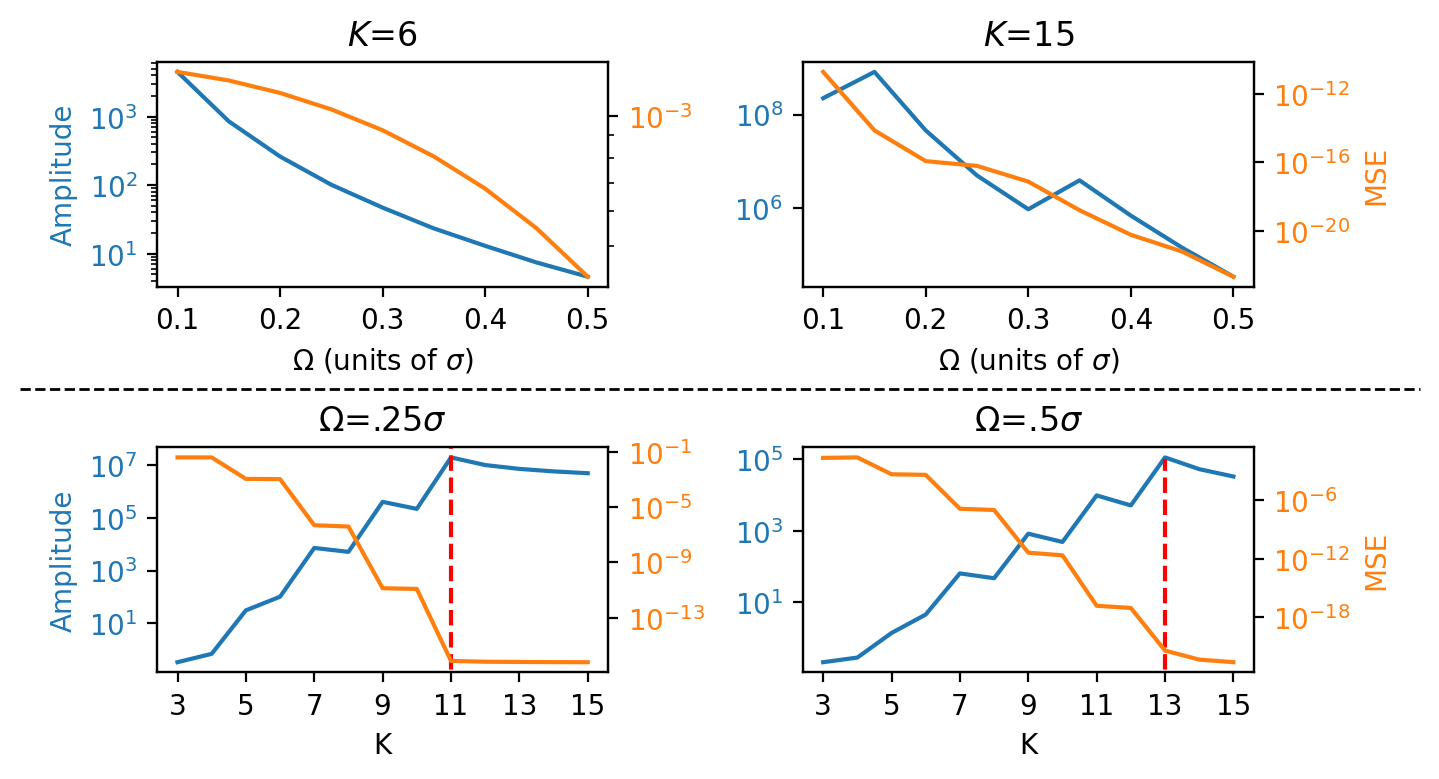

In [68]:
plt.rcParams['figure.dpi'] = 200
fig = plt.figure(figsize=(7, 4))
gs = fig.add_gridspec(2, 2, height_ratios=[0.5, 0.5])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

ax1.set_title(r'$K$=6')
ax1.plot(min_amp_O, color='tab:blue', label=r'amp')
ax1.set_xlabel(r'$\Omega$ (units of $\sigma$)')
ax1.set_ylabel('Amplitude', color='tab:blue')
ax1.set_yscale('log')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax1a = ax1.twinx()
ax1a.plot(min_mse_O, color='tab:orange', label=r'MSE')
ax1a.tick_params(axis='y', labelcolor='tab:orange', which='major')
ax1a.tick_params(axis='y', which='minor', labelright=False)
# ax1a.set_ylabel('MSE', color='tab:orange')
ax1a.set_yscale('log')

ax2.set_title(r'$K$=15')
ax2.plot(min_amp_O2, color='tab:blue', label=r'amp')
ax2.set_xlabel(r'$\Omega$ (units of $\sigma$)')
# ax2.set_ylabel('Amplitude', color='tab:blue')
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='tab:blue')

ax2a = ax2.twinx()
ax2a.plot(min_mse_O2, color='tab:orange', label=r'MSE')
ax2a.tick_params(axis='y', labelcolor='tab:orange', which='major')
ax2a.tick_params(axis='y', which='minor', labelright=False)
ax2a.set_ylabel('MSE', color='tab:orange')
ax2a.set_yscale('log')

ax3.set_title(r'$\Omega$=.25$\sigma$')
ax3.plot(min_amp_N, color='tab:blue', label=r'amp')
ax3.set_xlabel(r'K')
ax3.set_ylabel('Amplitude', color='tab:blue')
ax3.set_yscale('log')
ax3.set_xticks(range(3, 21, 2))
ax3.tick_params(axis='y', labelcolor='tab:blue')
ax3.vlines(11, 0, 3e8, linestyles='dashed', color='red')

ax3a = ax3.twinx()
ax3a.plot(min_mse_N, color='tab:orange', label=r'MSE')
# ax3a.set_ylabel('MSE', color='tab:orange')
ax3a.set_yscale('log')
ax3a.tick_params(axis='y', labelcolor='tab:orange')

ax4.set_title(r'$\Omega$=.5$\sigma$')
ax4.plot(min_amp_N2, color='tab:blue', label=r'amp')
ax4.set_xlabel(r'K')
# ax4.set_ylabel('Amplitude', color='tab:blue')
ax4.set_yscale('log')
ax4.set_xticks(range(3, 21, 2))
ax4.tick_params(axis='y', labelcolor='tab:blue')
ax4.vlines(13, 0, 1e5, linestyles='dashed', color='red')

ax4a = ax4.twinx()
ax4a.plot(min_mse_N2, color='tab:orange', label=r'MSE')
ax4a.set_ylabel('MSE', color='tab:orange')
ax4a.set_yscale('log')
ax4a.tick_params(axis='y', labelcolor='tab:orange')

line = Line2D([0, 1], [0.5, 0.5], transform=fig.transFigure, color="black", linestyle="--", linewidth=1)
fig.add_artist(line)

plt.tight_layout()
plt.show()

### amp and MSE as a function of omega_min for fixed N and Omega

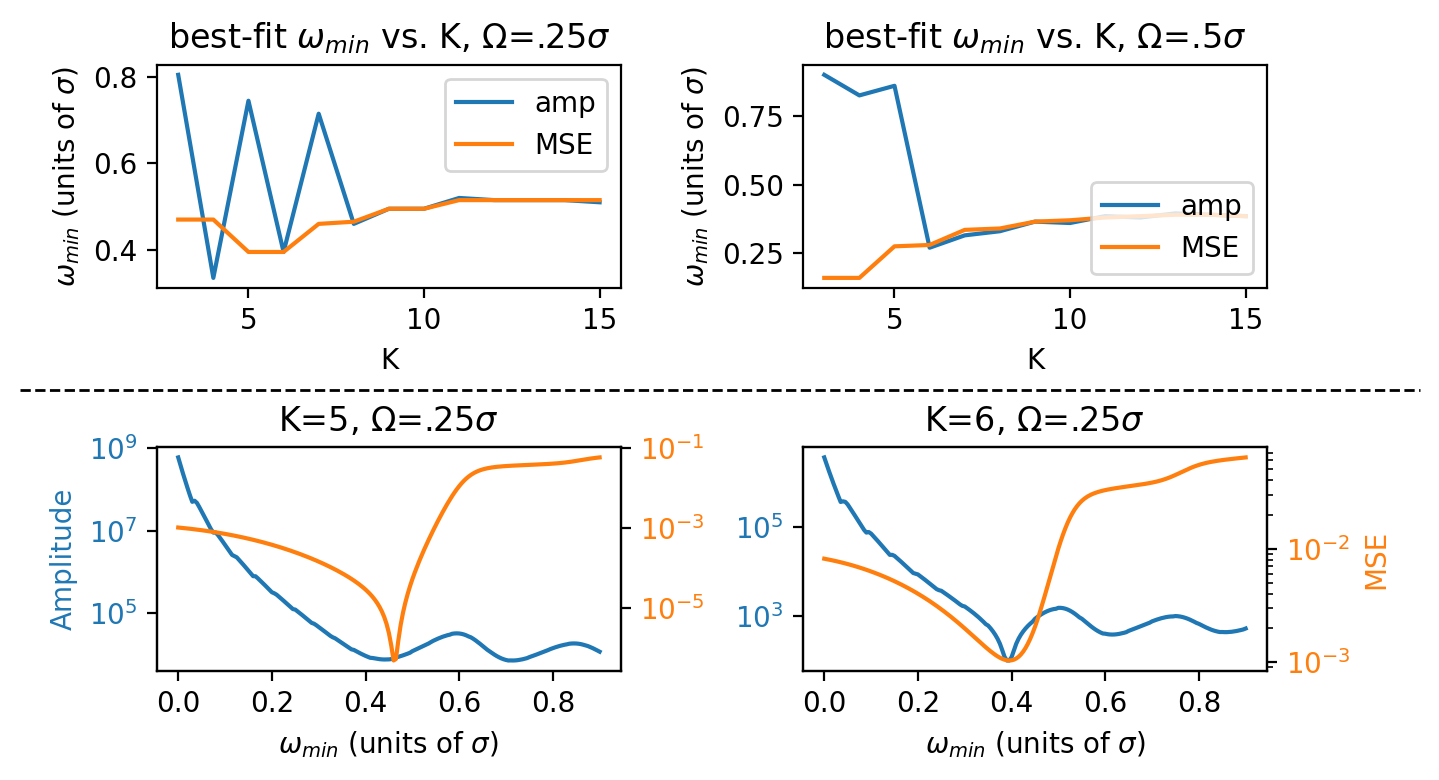

In [67]:
O25 = mins[mins['Omega'] == .25]
min_mse_rows = O25.loc[O25.groupby('N')['MSE'].idxmin()]
min_amp_rows = O25.loc[O25.groupby('N')['amp'].idxmin()]

O5 = mins[mins['Omega'] == .5]
min_mse_rows2 = O5.loc[O5.groupby('N')['MSE'].idxmin()]
min_amp_rows2 = O5.loc[O5.groupby('N')['amp'].idxmin()]

N6O25 = mins[(mins['N'] == 6) & (mins['Omega'] == .25)]
N5O25 = mins[(mins['N'] == 7) & (mins['Omega'] == .25)]

# Create the figure and the gridspec
fig = plt.figure(figsize=(7, 4))
gs = fig.add_gridspec(2, 2, height_ratios=[0.5, 0.5])

ax3 = fig.add_subplot(gs[0, 0])
ax4 = fig.add_subplot(gs[0, 1])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1])

ax1.set_title(r'K=5, $\Omega$=.25$\sigma$')
ax1.plot(N5O25['omega_min'], N5O25['amp'], color='tab:blue')
ax1.set_xlabel(r'$\omega_{min}$ (units of $\sigma$)')
ax1.set_ylabel('Amplitude', color='tab:blue')
ax1.set_yscale('log')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax1a = ax1.twinx()
ax1a.plot(N5O25['omega_min'], N5O25['MSE'], label='MSE', color='tab:orange')
ax1a.set_yscale('log')
ax1a.tick_params(axis='y', labelcolor='tab:orange')

ax2.set_title(r'K=6, $\Omega$=.25$\sigma$')
ax2.plot(N6O25['omega_min'], N6O25['amp'], color='tab:blue')
ax2.set_xlabel(r'$\omega_{min}$ (units of $\sigma$)')
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='tab:blue')

ax2a = ax2.twinx()
ax2a.plot(N6O25['omega_min'], N6O25['MSE'], label='MSE', color='tab:orange')
ax2a.set_ylabel('MSE', color='tab:orange')
ax2a.set_yscale('log')
ax2a.tick_params(axis='y', labelcolor='tab:orange')

ax3.plot(min_amp_rows['N'], min_amp_rows['omega_min'])
ax3.plot(min_mse_rows['N'], min_mse_rows['omega_min'])
ax3.set_title(r'best-fit $\omega_{min}$ vs. K, $\Omega$=.25$\sigma$')
ax3.set_xlabel('K')
ax3.set_ylabel(r'$\omega_{min}$ (units of $\sigma$)')
ax3.legend(['amp', 'MSE'], loc='upper right')

ax4.plot(min_amp_rows2['N'], min_amp_rows2['omega_min'])
ax4.plot(min_mse_rows2['N'], min_mse_rows2['omega_min'])
ax4.set_title(r'best-fit $\omega_{min}$ vs. K, $\Omega$=.5$\sigma$')
ax4.set_xlabel('K')
ax4.set_ylabel(r'$\omega_{min}$ (units of $\sigma$)')
ax4.legend(['amp', 'MSE'], loc='lower right')

line = Line2D([0, 1], [0.5, 0.5], transform=fig.transFigure, color="black", linestyle="--", linewidth=1)
fig.add_artist(line)

plt.tight_layout()
plt.show()